# `Принятие решений в бизнесе`

Вы — аналитик крупного интернет-магазина. Вместе с отделом маркетинга вы подготовили список гипотез для увеличения выручки.
Приоритизируйте гипотезы, запустите A/B-тест и проанализируйте результаты. 

**Описание данных**

*Данные для первой части.*

Файл /datasets/hypothesis.csv :

- Hypothesis — краткое описание гипотезы;
- Reach — охват пользователей по 10-балльной шкале;
- Impact — влияние на пользователей по 10-балльной шкале;
- Confidence — уверенность в гипотезе по 10-балльной шкале;
- Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.

*Данные для второй части.*

Файл /datasets/orders.csv :

- transactionId — идентификатор заказа;
- visitorId — идентификатор пользователя, совершившего заказ;
- date — дата, когда был совершён заказ;
- revenue — выручка заказа;
- group — группа A/B-теста, в которую попал заказ.

Файл /datasets/visitors.csv :

- date — дата;
- group — группа A/B-теста;
- visitors — количество пользователей в указанную дату в указанной группе A/B-теста

**План проекта**

Часть 1. Приоритизация гипотез:
- Применить фреймворк ICE для приоритизации гипотез. Отсортировать их по убыванию приоритета.
- Применить фреймворк RICE для приоритизации гипотез. Отсортировать их по убыванию приоритета.
- Указать, как изменилась приоритизация гипотез при применении RICE вместо ICE. Объяснить, почему так произошло.

Часть 2. Анализ А/В-теста:
1. Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения.
2. Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения.
3. Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения.
4. Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.
5. Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.
6. Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения.
7. Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей.
8. Постройте точечный график стоимостей заказов. Сделайте выводы и предположения.
9. Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов.
10. Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения.
11. Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения.
12. Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения.
13. Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения.
14. Примите решение по результатам теста и объясните его. Варианты решений:
      1. Остановить тест, зафиксировать победу одной из групп.
      2. Остановить тест, зафиксировать отсутствие различий между группами.
      3. Продолжить тест.

**Подключаем все необходимые библиотеки**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
import datetime as dt
from pandas.plotting import register_matplotlib_converters
import warnings
# конвертеры, которые позволяют использовать типы pandas в matplotlib  
register_matplotlib_converters()
pd.set_option('display.max_colwidth', 500)

## Загрузка и анализ данных

Загрузим и проанализируем данные о гипотезах, пользователях и заказах.

In [2]:
hypothesis = pd.read_csv('hypothesis.csv')
orders = pd.read_csv('orders.csv', parse_dates=['date'])
visitors = pd.read_csv('visitors.csv', parse_dates=['date'])

In [3]:
def explore_dataframe(df, table_name, print_head=5, print_info=True):
    
    print(f"Анализ таблицы: {table_name}")
    
    # Вывод первых n строк
    print(f"Первые {print_head} строк таблицы:")
    display(df.head(print_head))
    
    # Вывод информации о DataFrame
    if print_info:
        print("\nИнформация о таблице:")
        df.info()
    
    # Анализ пропусков
    print("\nКоличество и процент пропусков в датафрейме:")
    missing_report = df.isna().sum().to_frame()
    missing_report = missing_report.rename(columns={0: 'missing_values'})
    missing_report['% of total'] = (missing_report['missing_values'] / df.shape[0]).round(2)
    display(missing_report.sort_values(by='missing_values', ascending=False))
    
    # Анализ дубликатов
    print("\nКоличество явных дубликатов:", df.duplicated().sum())
    
    # Анализ распределения численных значений
    print("\nОписательная статистика таблицы:")
    display(df.describe())
    
    # Анализ частоты категориальных значений
    categorical_cols = df.select_dtypes(include='object').columns
    for col in categorical_cols:
        print(f"\nЧастота значений в столбце '{col}':")
        display(df[col].value_counts())

### Датафрейм с информацией о гипотезах

In [4]:
explore_dataframe(hypothesis, '9 гипотез по увеличению выручки интернет-магазина с указанными параметрами')

Анализ таблицы: 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами
Первые 5 строк таблицы:


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1



Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes

Количество и процент пропусков в датафрейме:


,missing_values,% of total
Hypothesis,0,0.0
Reach,0,0.0
Impact,0,0.0
Confidence,0,0.0
Efforts,0,0.0



Количество явных дубликатов: 0

Описательная статистика таблицы:


,Reach,Impact,Confidence,Efforts
count,9.000000,9.000000,9.000000,9.000000
mean,4.777778,4.777778,5.555556,4.888889
std,3.153481,3.192874,3.045944,2.803767
min,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,3.000000
50%,3.000000,3.000000,7.000000,5.000000
75%,8.000000,7.000000,8.000000,6.000000
max,10.000000,10.000000,9.000000,10.000000



Частота значений в столбце 'Hypothesis':


Hypothesis
Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей              1
Запустить собственную службу доставки, что сократит срок доставки заказов                                       1
Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа    1
Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар             1
Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей                                1
Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов                        1
Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию            1
Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок                1
Запустить акцию, дающую скидку на товар в день рождения                      

**Вывод**

В таблице с данными о гипотезах все столбцы приведены к нужному типу данных, отсутствуют явные и неявные дубликаты, все данные полные - пропусков нет.

Для дальнейшего удобства работы с таблицей приведем все названия столбцов к нижнему регистру.

In [5]:
hypothesis.columns = hypothesis.columns.str.lower().str.replace(' ', '_')
display(hypothesis.columns)

Index(['hypothesis', 'reach', 'impact', 'confidence', 'efforts'], dtype='object')

### Датафрейм с информацией о заказах

In [6]:
explore_dataframe(orders, 'Данные о заказах')

Анализ таблицы: Данные о заказах
Первые 5 строк таблицы:


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B



Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB

Количество и процент пропусков в датафрейме:


,missing_values,% of total
transactionId,0,0.0
visitorId,0,0.0
date,0,0.0
revenue,0,0.0
group,0,0.0



Количество явных дубликатов: 0

Описательная статистика таблицы:


,transactionId,visitorId,date,revenue
count,1.197000e+03,1.197000e+03,1197,1.197000e+03
mean,2.155621e+09,2.165960e+09,2019-08-15 13:06:46.015037696,8.348006e+03
min,1.062393e+06,5.114589e+06,2019-08-01 00:00:00,5.000000e+01
25%,1.166776e+09,1.111826e+09,2019-08-08 00:00:00,1.220000e+03
50%,2.145194e+09,2.217985e+09,2019-08-15 00:00:00,2.978000e+03
75%,3.237740e+09,3.177606e+09,2019-08-23 00:00:00,8.290000e+03
max,4.293856e+09,4.283872e+09,2019-08-31 00:00:00,1.294500e+06
std,1.229085e+09,1.236014e+09,NaN,3.919113e+04



Частота значений в столбце 'group':


group
B    640
A    557
Name: count, dtype: int64

**Вывод**

В таблице с данными о заказах все столбцы приведены к нужному типу данных, отсутствуют явные и неявные дубликаты, все данные полные - пропусков нет.

Некоторые названия столбцов плохо читаемы, поэтому поменяем ID на _id. 

In [7]:
orders.columns = orders.columns.str.replace('Id', '_id')
orders.columns

Index(['transaction_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='object')

### Датафрейм с информацией о пользователях

In [8]:
explore_dataframe(visitors, 'Данные о пользователях')

Анализ таблицы: Данные о пользователях
Первые 5 строк таблицы:


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756



Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB

Количество и процент пропусков в датафрейме:


,missing_values,% of total
date,0,0.0
group,0,0.0
visitors,0,0.0



Количество явных дубликатов: 0

Описательная статистика таблицы:


,date,visitors
count,62,62.000000
mean,2019-08-16 00:00:00,607.290323
min,2019-08-01 00:00:00,361.000000
25%,2019-08-08 06:00:00,534.000000
50%,2019-08-16 00:00:00,624.500000
75%,2019-08-23 18:00:00,710.500000
max,2019-08-31 00:00:00,770.000000
std,NaN,114.400560



Частота значений в столбце 'group':


group
A    31
B    31
Name: count, dtype: int64

**Вывод**

В таблице с данными о пользователях все столбцы приведены к нужному типу данных, отсутствуют явные и неявные дубликаты, названия столбцов приведены к нужному типу, все данные полные - пропусков нет.

In [9]:
start_date = min(visitors['date'])
end_date = max(visitors['date'])
print(f"Даты начала и окончания теста: {start_date} и {end_date}")

Даты начала и окончания теста: 2019-08-01 00:00:00 и 2019-08-31 00:00:00


А/В тест продолжался на протяжении месяца - с 1 августа 2019 по 31 августа 2019 года.

In [10]:
num_groups = visitors['group'].nunique()
print(f"Количество групп в АВ-тесте: {num_groups}")

Количество групп в АВ-тесте: 2


In [11]:
# Получение списка уникальных пользователей
all_users = orders['visitor_id'].unique()

# Определение группы для каждого пользователя
user_groups = orders.groupby('visitor_id')['group'].apply(set).to_dict()

# Подсчет количества пользователей, попавших в обе группы
overlapping_users = sum(len(group) > 1 for group in user_groups.values())
total_users = len(all_users)

print(f"Количество пользователей попавших в обе группы: {overlapping_users}")
print(f"Вероятность попадания пользователей в обе группы: {(overlapping_users / total_users):.2%}")


Количество пользователей попавших в обе группы: 58
Вероятность попадания пользователей в обе группы: 5.63%


## Часть 1. Приоритизация гипотез.

### Применим фреймворк ICE для приоритизации гипотез. Отсортируем их по убыванию приоритета.

In [12]:
hypothesis['ICE']=((hypothesis['impact']*hypothesis['confidence'])/hypothesis['efforts']).round(2)

hypothesis.sort_values(by='ICE', ascending=False)

,hypothesis,reach,impact,confidence,efforts,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


В явные лидеры выбилась гипотеза под номером 8 - "Запустить акцию, дающую скидку на товар в день рождения". 

У 8 гипотезы очень хорошие показатели Impact и Confidence. Скидка в день рождения повлияет на пользовательский опыт и удовлетворение от продукта в лучшую сторону почти со 100% вероятностью. Показатель Efforts отвечает за стоимость тестирования гипотезы, здесь он средний, тк запустить акцию в день рождения клиента не должно вызвать больших затрат.   

На втором месте гипотеза под номером 0 - "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей", на третьем месте 7 гипотеза - "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок".

### Применим фреймворк RICE для приоритизации гипотез. Отсортируем их по убыванию приоритета.

In [13]:
hypothesis['RICE']=(hypothesis['reach']*hypothesis['impact']*hypothesis['confidence'])/hypothesis['efforts']

hypothesis.sort_values(by='RICE', ascending=False)

,hypothesis,reach,impact,confidence,efforts,ICE,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.0


На первом месте находится 7 гипотеза - "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок".

Показатель Reach максимальный, значит изменение затронет абсолютно каждого пользователя. Impact данной гипотезы равен 7, то есть подписка окажет существенное влияние на пользовательский опыт. Confidence составляет 8 баллов, следовательно уверенность в оценках других параметров велика. Проверка гипотезы средняя, больших затрат и разработки не потребует.

На втором месте находится гипотеза 2 - "Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа", на третьем месте гипотеза 0 - "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей".


### Укажим, как изменилась приоритизация гипотез при применении RICE вместо ICE. Объясним, почему так произошло.

Приоритизация гипотез при применении RICE изменилась - другие гипотезы вышли на лидирующие позиции. Так, например, акция в день рождения с 1 места опустилась до 5. 

Такое изменение произошло из-за того, что в ICE параметр Reach не имеет значения, но у RICE, если этот параметр вместе с Impact и Confidence малы, то гипотеза с большой вероятностью не займёт приоритетную позицию. 

**Вывод**

Наиболее приоритетные гипотезы по фреймворку ICE:

1. "Запустить акцию, дающую скидку на товар в день рождения".
2. "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей".
3. "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок".

Наиболее приоритетные гипотезы по фреймворку RICE:

1. "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок".
2. "Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа".
3. "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей".

Исходя из результатов двух фреймворков для проведения А/В теста стоит взять гипотезу под номером 7 - "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок".

## Часть 2. Анализ A/B-теста

### Постройте график кумулятивной выручки по группам. Сделайте выводы и предположения.

In [14]:
# создаем массив уникальных пар значений дат и групп теста
dates_groups = orders[['date','group']].drop_duplicates() 

orders_aggregated = dates_groups.apply(
    lambda x: orders[
        np.logical_and(
            orders['date'] <= x['date'], orders['group'] == x['group'])
    ].agg(
        {
            'date' : 'max', 
            'group' : 'max', 
            'transaction_id' : 'nunique', 
            'visitor_id' : 'nunique', 
            'revenue' : 'sum'
        }
    ), axis=1).sort_values(by=['date','group'])


visitors_aggregated = dates_groups.apply(
    lambda x: visitors[
        np.logical_and(
            visitors['date'] <= x['date'], visitors['group'] == x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])

cumulative_data = orders_aggregated.merge(
    visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulative_data.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]

display(orders_aggregated.head())
display(visitors_aggregated.head())
display(cumulative_data.head())

,date,group,transaction_id,visitor_id,revenue
55,2019-08-01,A,24,20,148579
66,2019-08-01,B,21,20,101217
175,2019-08-02,A,44,38,242401
173,2019-08-02,B,45,43,266748
291,2019-08-03,A,68,62,354874


,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845


,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338
3,2019-08-02,B,45,43,266748,1294
4,2019-08-03,A,68,62,354874,1845


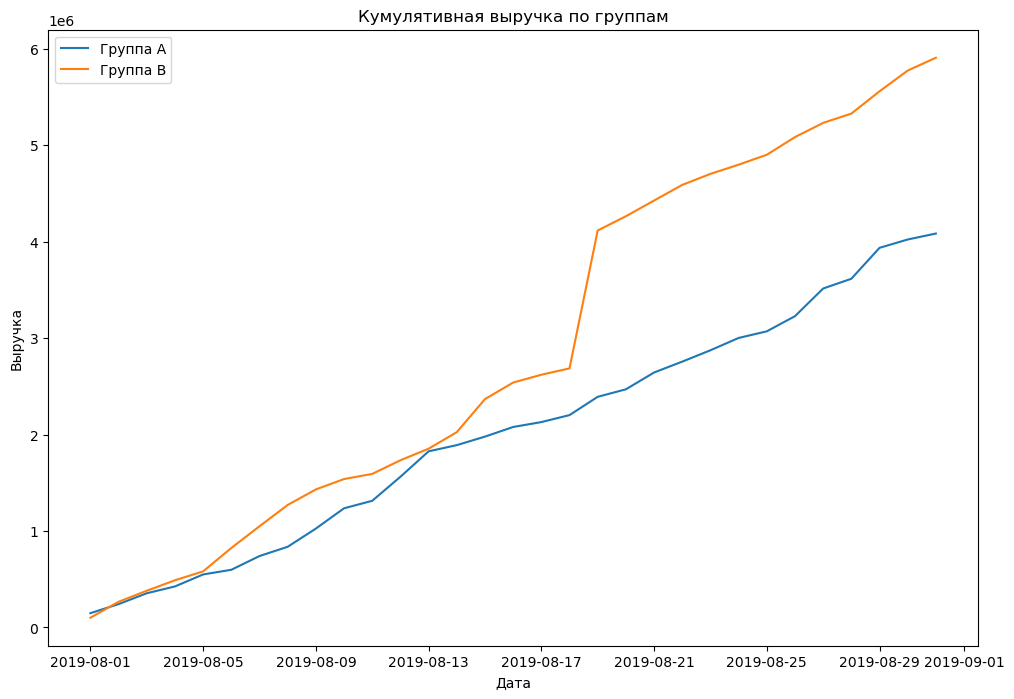

In [15]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_A = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_B = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(12,8))  

# Строим график выручки группы А
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'], label='B')

plt.legend(['Группа А', 'Группа B']) 
plt.xlabel('Дата')
plt.ylabel('Выручка') 
plt.title('Кумулятивная выручка по группам')

plt.show()

До 18 августа выручка почти равномерно увеличивается, затем у группы В произошёл резкий скачок в выручке. Это может сигнализировать о всплесках числа заказов, либо о появлении очень дорогих заказов в выборке. 

Со 2 августа на протяжении всего теста лидирует группа В.

### Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения.

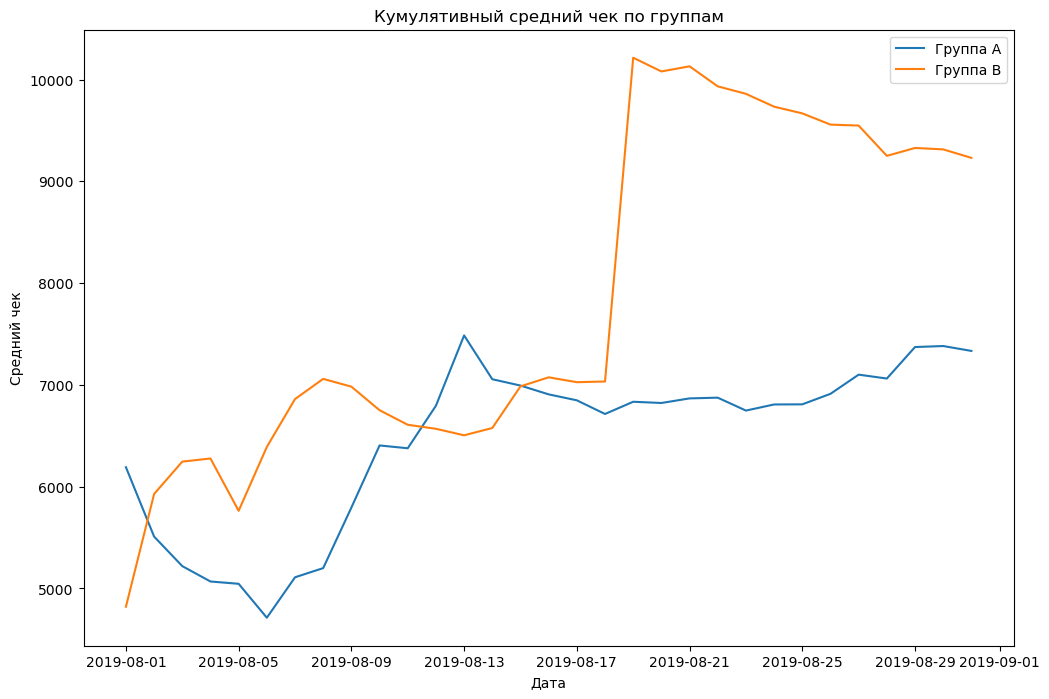

In [16]:
plt.figure(figsize=(12,8)) 
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue']/cumulative_revenue_A['orders'], label='A')
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue']/cumulative_revenue_B['orders'], label='B')

plt.legend(['Группа А', 'Группа B']) 
plt.xlabel('Дата')
plt.ylabel('Средний чек') 
plt.title('Кумулятивный средний чек по группам')

plt.show()

Оба графика в первой половине теста ведут себя непредсказуемо: есть сильный рост, а также резкие падения. 

У группы В, также как и на графике выручки по дням, наблюдается резкий скачок 18 авгусата - средний чек заказа вырос до 10 тысяч.

Средний чек начинает стабилизироваться ближе к концу теста: для группы В заметен небольшой спад, у группы А заметен рост.

### Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения.

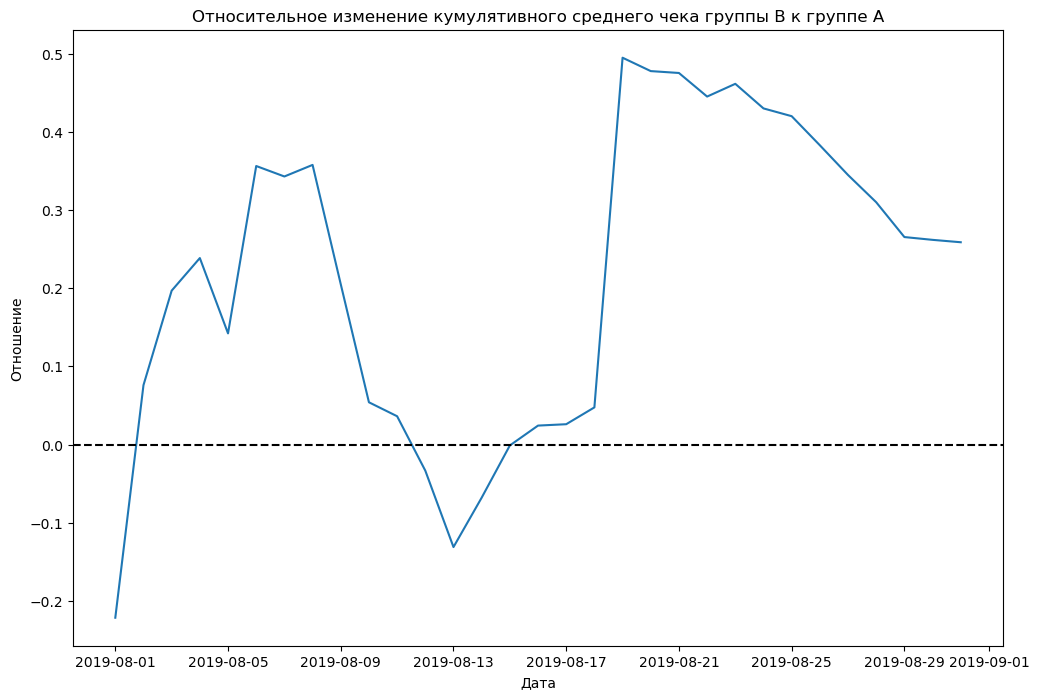

In [17]:
plt.figure(figsize=(12,8)) 
# собираем данные в одном датафрейме
merged_cumulative_revenue = cumulative_revenue_A.merge(cumulative_revenue_B, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# cтроим отношение средних чеков
plt.plot(merged_cumulative_revenue['date'], (merged_cumulative_revenue['revenueB']/merged_cumulative_revenue['ordersB'])/(merged_cumulative_revenue['revenueA']/merged_cumulative_revenue['ordersA'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--');

plt.xlabel('Дата')
plt.ylabel('Отношение') 
plt.title('Относительное изменение кумулятивного среднего чека группы B к группе A')

plt.show()

В нескольких точках график различия между сегментами резко «скачет». Это может означать, что именно в эти скачки были совершены крупные заказы. 

### Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.

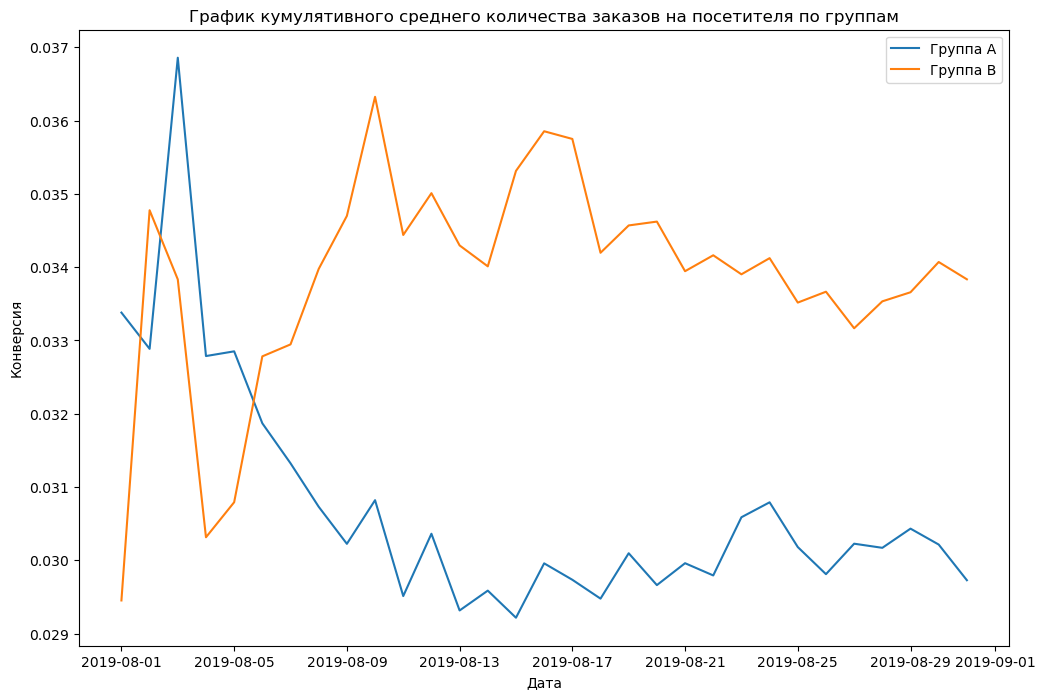

In [18]:
# считаем среднее количество заказов на посетителя
cumulative_data['conversion'] = cumulative_data['orders']/cumulative_data['visitors']

# отделяем данные по группе A
cumulative_data_A = cumulative_data[cumulative_data['group']=='A']

# отделяем данные по группе B
cumulative_data_B = cumulative_data[cumulative_data['group']=='B']


plt.figure(figsize=(12,8))
# строим графики
plt.plot(cumulative_data_A['date'], cumulative_data_A['conversion'], label='A')
plt.plot(cumulative_data_B['date'], cumulative_data_B['conversion'], label='B')

plt.legend(['Группа А', 'Группа B'])
plt.xlabel('Дата')
plt.ylabel('Конверсия') 
plt.title('График кумулятивного среднего количества заказов на посетителя по группам')

plt.show()


До 6 августа конверсия группы А была больше, но затем у группы В среднее количество заказов вырвалось вперёд и начало потихоньку фиксироваться, у группы А конверсия просела.

### Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.

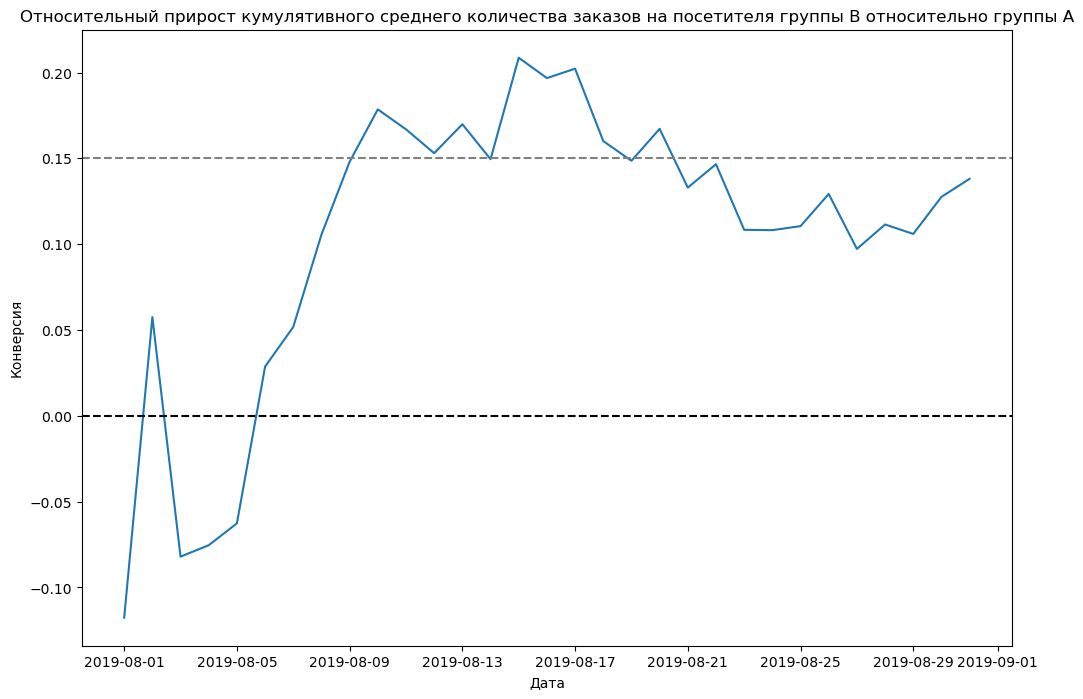

In [19]:

merged_cumulative_conversions = cumulative_data_A[['date','conversion']].merge(cumulative_data_B[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.figure(figsize=(12,8))

plt.plot(merged_cumulative_conversions['date'], merged_cumulative_conversions['conversionB']/merged_cumulative_conversions['conversionA']-1)

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.15, color='grey', linestyle='--');

plt.xlabel('Дата')
plt.ylabel('Конверсия') 
plt.title('Относительный прирост кумулятивного среднего количества заказов на посетителя группы B относительно группы A')

plt.show()

В начале теста группа B значительно проигрывала группе A, затем вырвалась вперёд. Потом среднее количество заказов на посетителя для группы B снова уменьшалось, но в конце теста начало постепенно расти.

Отношение среднего количества заказов на посетителя с 9 августа по 21 колебалось в диапазоне от 15% до 20%, в конце месяца снизилось до 10-15%. 

### Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения.

In [20]:
orders_count = (orders.groupby('visitor_id')
                .agg({'transaction_id':'nunique'})
               .rename(columns={'visitor_id': 'user_id',
                                'transaction_id':'orders_count'})
               .reset_index())
orders_count.sort_values(by='orders_count', ascending=False).head(10)

,visitor_id,orders_count
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


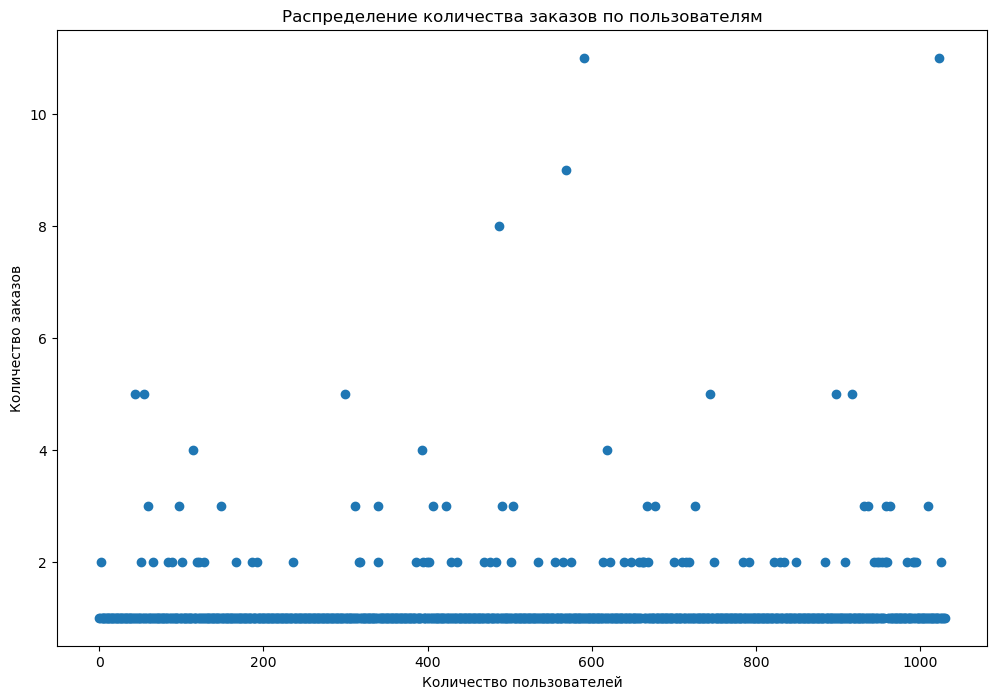

In [21]:
x_values = pd.Series(range(0,len(orders_count['orders_count'])))
plt.figure(figsize=(12,8))
plt.scatter(x_values, orders_count['orders_count'])

plt.xlabel('Количество пользователей')
plt.ylabel('Количество заказов') 
plt.title('Распределение количества заказов по пользователям')

plt.show()

Выбросы подтвердились, есть пользователи, которые совершали 5 и больше заказов. 

Чаще всего пользоваетели совершали только 1 заказ, но 2 заказа тоже не редкость. 

### Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей.

In [22]:
print(np.percentile(orders_count['orders_count'], [95, 99])) 

[2. 4.]


Не более 5% пользователей совершили больше двух заказов.

Больше четырёх заказов совершили не более 1% пользователей.

Исходя из точечного графика и подсчёта перцентилей, для определения аномальных пользователей стоит выбрать границу в три заказа.

### Постройте точечный график стоимостей заказов. Сделайте выводы и предположения.

In [23]:
orders.sort_values(by='revenue', ascending=False).head(10)

,transaction_id,visitor_id,date,revenue,group
425,590470918,1920142716,2019-08-19,1294500,B
1196,3936777065,2108080724,2019-08-15,202740,B
858,192721366,1316129916,2019-08-27,93940,A
1136,666610489,1307669133,2019-08-13,92550,A
744,3668308183,888512513,2019-08-27,86620,B
682,1216533772,4266935830,2019-08-29,78990,B
662,1811671147,4266935830,2019-08-29,78990,A
743,3603576309,4133034833,2019-08-09,67990,A
1103,1348774318,1164614297,2019-08-12,66350,A
1099,316924019,148427295,2019-08-12,65710,A


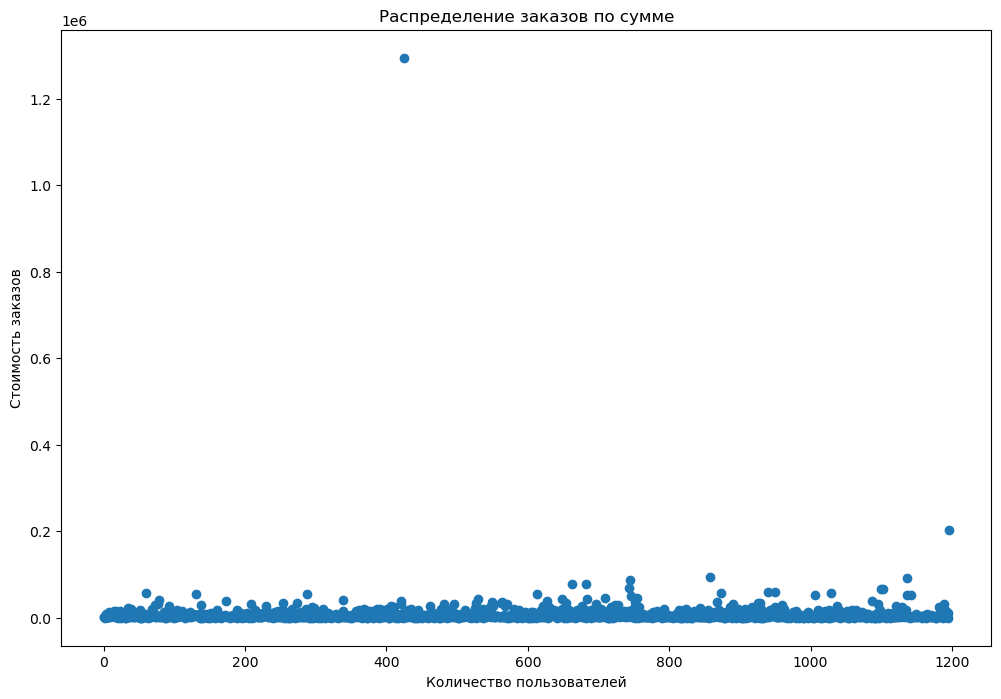

In [24]:
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.figure(figsize=(12,8))
plt.scatter(x_values, orders['revenue'])

plt.xlabel('Количество пользователей')
plt.ylabel('Стоимость заказов') 
plt.title('Распределение заказов по сумме')

plt.show()

На графике есть дорогой заказ стоимостью более 1.2 млн рублей и заказ стоимостью около 200 тысяч, все остальные не дороже 100 тысяч. 

Увеличим график, чтобы детальнее рассмотреть распределение стоимостей заказов.

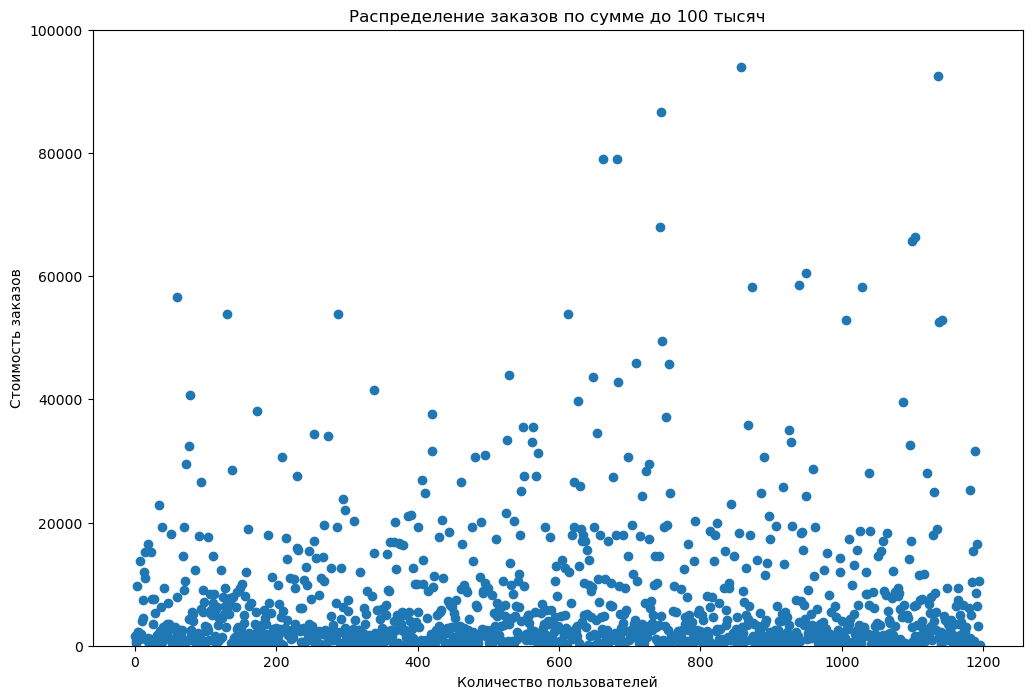

In [25]:
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.figure(figsize=(12,8))
plt.scatter(x_values, orders['revenue']);
plt.ylim(0, 100000) 

plt.xlabel('Количество пользователей')
plt.ylabel('Стоимость заказов') 
plt.title('Распределение заказов по сумме до 100 тысяч')

plt.show()

Большинство заказов не превышают 20 тысяч.

### Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов.

In [26]:
print(np.percentile(orders['revenue'], [95, 99])) 

[28000.  58233.2]


Не более одного 1% пользователей совершают покупки на сумму больше 58233 рублей, не более 5% заказов стоимостью дороже 28 тысяч. 

Зададим границу для определения аномальных заказов в 30 тысяч. 

### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения.

Для дальнейших подсчётов будем использовать непараметрический тест Манна-Уитни.

Пороговый уровень альфа зададим в 5%.

In [27]:
alpha = 0.05

In [28]:
orders_by_users_A = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
orders_by_users_A.columns = ['visitor_id', 'orders']

orders_by_users_B = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
orders_by_users_B.columns = ['visitor_id', 'orders']

Подготовим выборки количества заказов по пользователям по группам теста:

In [29]:

sample_A = pd.concat(
    [
        orders_by_users_A['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group']=='A']['visitors'].sum() - len(orders_by_users_A['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sample_B = pd.concat(
    [
        orders_by_users_B['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group']=='B']['visitors'].sum() - len(orders_by_users_B['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

Выдвигаем гипотезу: 
- **$H_{0}$** (нулевая): различий в среднем количестве заказов на посетителя между группами в "сырых" данных нет;
- **$H_{1}$** (альтернативная): различия в среднем количестве заказов на посетителя между группами в "сырых" данных есть.

In [30]:
results_1 = st.mannwhitneyu(sample_A, sample_B)[1] # ваш код

print('p-значение: ', results_1)

if results_1 < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя'
    )
    
print("Относительный прирост группы B: {0:.2f}%".format((sample_B.mean() / sample_A.mean() - 1) * 100))

p-значение:  0.016792355056752608
Отвергаем нулевую гипотезу: разница статистически значима
Относительный прирост группы B: 13.81%


Значение p-value = 0.0168 оказалось меньше порогового уровня, значит нулевая гипотеза отвергается и, следовательно, в среднем числе заказов между группами есть статистически значимые различия. 

Относительные прирост группы В, то есть отношение конверсии В к А, составляет 13.81%, что является неплохим результатом.


### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения.

Выдвигаем гипотезу: 
- **$H_{0}$** (нулевая): различий в среднем чеке заказа между группами по "сырым" данным нет;
- **$H_{1}$** (альтернативная):  различия в среднем чеке заказа между группами по "сырым" данным  есть.

In [31]:
results_2 = st.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]

print('p-значение: ', results_2)

if results_2 < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя'
    )
    
print("Относительный прирост группы B: {0:.2f}%".format((orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1) * 100)) 


p-значение:  0.7292909855432458
Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя
Относительный прирост группы B: 25.87%


По «сырым» данным различий в среднем чеке заказа между группами A и B нет. 
p-value = 0.729 больше 0.05, значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, не отвергаем. Однако относительный прирост группы B равен 25.87%.

### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения.

Ранее было принято, что "очищенными" данными будут считаться те, где количество заказов не превышает трёх и стоимость заказов не больше 30 тысяч.

In [32]:
usersWithManyOrders = pd.concat(
    [
        orders_by_users_A[orders_by_users_A['orders'] >= 4]['visitor_id'],
        orders_by_users_B[orders_by_users_B['orders'] >= 4]['visitor_id'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > 30000]['visitor_id']
abnormal_users = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
print(abnormal_users.head(5))
print(abnormal_users.shape[0])

1099    148427295
18      199603092
928     204675465
23      237748145
684     358944393
Name: visitor_id, dtype: int64
57


Всего 57 аномальных пользователей. 
Узнаем, как их действия повлияли на результаты теста. Посчитаем статистическую значимость различий в среднем количестве заказов между группами теста по очищенным данным. 

Сначала подготовим выборки количества заказов по пользователям по группам теста:

In [33]:
sample_A_filtered = pd.concat(
    [
        orders_by_users_A[
            np.logical_not(orders_by_users_A['visitor_id'].isin(abnormal_users))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group']=='A']['visitors'].sum() - len(orders_by_users_A['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sample_B_filtered = pd.concat(
    [
        orders_by_users_B[
            np.logical_not(orders_by_users_B['visitor_id'].isin(abnormal_users))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group']=='B']['visitors'].sum() - len(orders_by_users_B['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)


Выдвигаем гипотезу: 
- **$H_{0}$** (нулевая): различий в среднем количестве заказов на посетителя между группами по "очищенным" данным нет;
- **$H_{1}$** (альтернативная): различия в среднем количестве заказов на посетителя между группами по "очищенным" данным есть.

In [34]:
results_3 = st.mannwhitneyu(sample_A_filtered, sample_B_filtered)[1]

print('p-значение: ', results_3)

if results_3 < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя'
    )
    
print("Относительный прирост группы B: {0:.2f}%".format((sample_B_filtered.mean()/sample_A_filtered.mean()-1)*100))


p-значение:  0.01831750089424907
Отвергаем нулевую гипотезу: разница статистически значима
Относительный прирост группы B: 14.75%


p-value = 0.0183 меньше порогового уровня, значит различия в среднем чеке заказа между группами А и В по «очищенным» данным также есть.

Относительный прирост группы В, то есть отношение конверсии В к А, составляет 14.75%.

Результаты не сильно отличаются от полученных по "сырым данным", разница прироста составляет около 2%.

### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения.

Выдвигаем гипотезу: 
- **$H_{0}$** (нулевая): различий в среднем чеке заказа между группами по "очищенным" данным нет;
- **$H_{1}$** (альтернативная):  различия в среднем чеке заказа между группами по "очищенным" данным  есть.

In [35]:
results_4 = st.mannwhitneyu(
            orders[
                np.logical_and(
                    orders['group'] == 'A',
                    np.logical_not(orders['visitor_id'].isin(abnormal_users)),
                )
            ]['revenue'],
            orders[
                np.logical_and(
                    orders['group'] == 'B',
                    np.logical_not(orders['visitor_id'].isin(abnormal_users)),
                )
            ]['revenue'],
        )[1]

print('p-значение: ', results_4)

if results_4 < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя'
    )

print(
    "Относительный прирост группы B: {0:.2f}%".format((
        orders[
            np.logical_and(
                orders['group'] == 'B',
                np.logical_not(orders['visitor_id'].isin(abnormal_users)),
            )
        ]['revenue'].mean()
        / orders[
            np.logical_and(
                orders['group'] == 'A',
                np.logical_not(orders['visitor_id'].isin(abnormal_users)),
            )
        ]['revenue'].mean()
        - 1
    ) * 100)
)

p-значение:  0.9583231483662625
Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя
Относительный прирост группы B: -1.97%


По «очищенным» данным различий в среднем чеке заказа между группами A и B нет. 
p-value = 0.958 больше 0.05, значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет, не отвергаем. Относительный проигрыш группы B равен почти 2%.

P-value существенно увеличился, но разница между сегментами сократилась с 26% до -2%, то есть конверсии группы В и А практически сравнялись.

**Вывод**

Результаты решённых задач:
- Есть статистически значимое различие по конверсии между группами как по сырым данным, так и после фильтрации аномалий.
- По сырым и очищенным данным нет статистически значимого различия по среднему чеку между группами. 
- По сырым и очищенным данным есть статистически значимое различие по среднему количеству заказов между группами. 
- График различия среднего количества заказов между группами сообщает, что результаты группы B намного лучше группы A и значительной тенденции к снижению не наблюдается.
- График различия среднего чека говорит о том, что результаты группы B растут скачкообразно и после значительного роста есть тенденция на снижение.

### Примите решение по результатам теста и объясните его. Варианты решений:
1. Остановить тест, зафиксировать победу одной из групп.
2. Остановить тест, зафиксировать отсутствие различий между группами.
3. Продолжить тест.

По результатам теста принято решение продолжить тест из-за нехватки информации для полноценного выбора группы. 

Как у "сырых", так и у "очищенных" данных по среднему чеку заказа различий не наблюдается. Более того после фильтрации практически стабилизировалось отношение конверсии группы В к группе А, значит по этому пункту различия между группами отсутствуют.

По "сырым" и "очищенным" данным есть статистически значимое различие по среднему количеству заказов на пользователя. Относительный прирост группы В к группе А изменился незначительно и стал выше на 2%, значит логичнее предположить, что победила группа В.

Также графики не дают уверенности в том, что все значения под конец теста зафиксировались, их колебания ещё значительны. Особенно на графике "относительного изменения кумулятивного среднего чека группы В к группе А" есть тенденция к снижению значения В.

**Вывод**

Исходя из вышесказанного, результаты всех наблюдений протеворечивы и тест стоит продолжить.
 